# Advanced Macroeconomics
## Dynamic Programming & Reinforcement Learning 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dynamic_programming.bellman_operator import BellmanOperator
from src.problem.opti_problem import CES

### Question 1 & 2

An agent has the opportunity to allocate her time between producing the consumption good C, and accumulating human capital H. Her intertemporal optimization problem is has follow:

$$\sum_{t=0}^{+\infty} \beta^t U(C_t)$$

subject to the following constraints: 
1. The production function, $\forall t, C_t = H_t^\alpha L_t$
2. The state transition equation, $\forall t, H_{t+1} = (1-\delta)H_t + 1 - L_t$
3. The control domain, $\forall t, L_{t} \in [0,1]$

Assuming a CRRA utility, the recursive problem is given by:

$$V(H_t) = \max_{L_t \in [0,1]} \left[\frac{(H_t^\alpha L_t)^{1-\sigma}}{1-\sigma} + \beta V((1-\delta)H_t + 1 - L_t)\right]$$

where the value function V is not known and is to determine.

In [2]:
# Grid
grid = np.linspace(1e-3, 5, 4000)

# Initial conditions and shocks
init_w = 0.5 * np.log(grid)

In [3]:
# Computation of the value function
recursive_solver = BellmanOperator(init_w=init_w, grid=grid)
recursive_solver.solve_optgrowth()

Recursive Solver:  22%|██▏       | 111/500 [00:23<01:22,  4.72iter/s, Error=9.36e-5] 


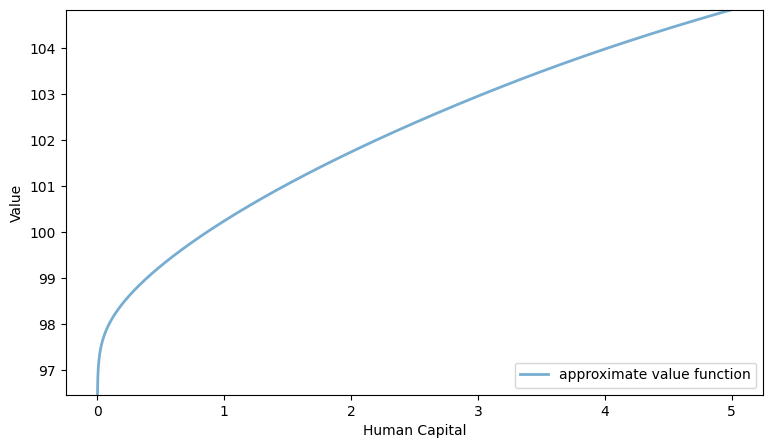

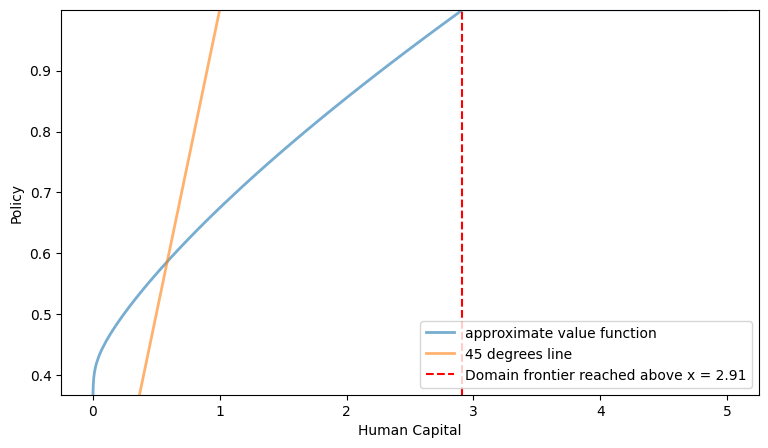

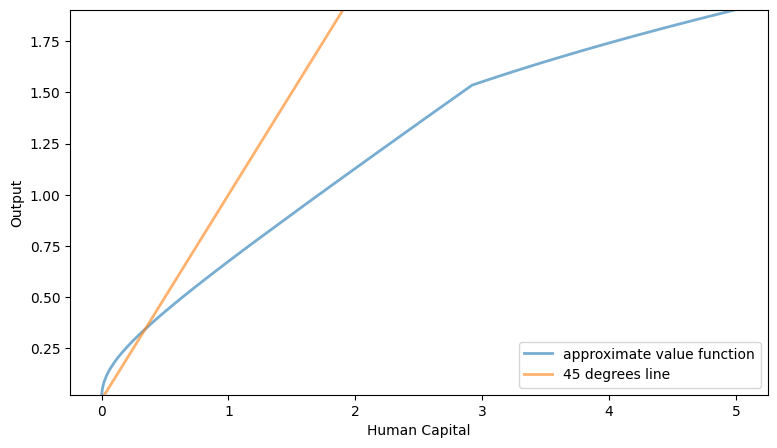

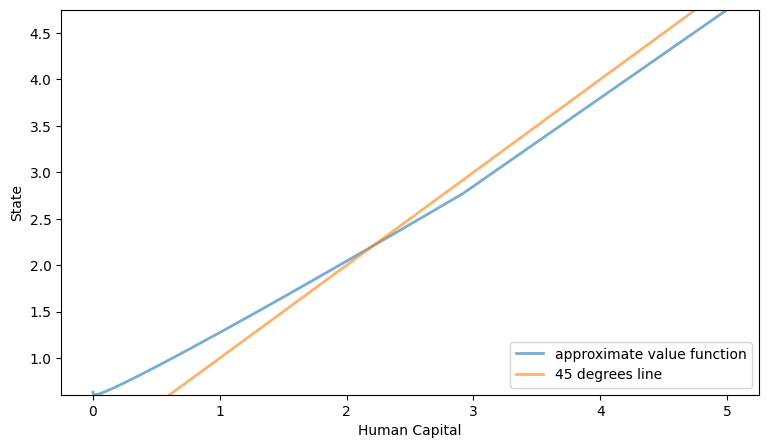

In [4]:
recursive_solver.plot_results("Value")
recursive_solver.plot_results("Policy", control_bound=(0, 1 - 1e-3))
recursive_solver.plot_results("Output")
recursive_solver.plot_results("State")

In [5]:
recursive_results = recursive_solver.get_results()

The recursive methods is valid when the optimal path of control lies in the interior of it's domain. Thus above the red doted line we are not sure about our approximation of the value function.

### Question 3 & 4

$$V(H_t) = \max_{H_{t+1} \in \Gamma(H_t)} \left[\frac{(H_t^\alpha ((1-\delta)H_t + 1 - H_{t+1}))^{1-\sigma}}{1-\sigma} + \beta V(H_{t+1})\right]$$

where $\Gamma(H_t) = [(1-\delta)H_t, (1-\delta)H_t + 1]$


In [6]:
from src.dynamic_programming.epsilon_greedy import EpsilonGreedy
from src.utils.plot import compare_approx

In [8]:
greedy_solver = EpsilonGreedy(init_w=init_w, grid=grid, epsilon=0)
greedy_solver.solve_optgrowth(max_iter=200)

Greedy Solver:   0%|          | 0/200 [00:00<?, ?iter/s]

109


Greedy Solver:   0%|          | 1/200 [00:01<04:44,  1.43s/iter, Error=0.682]

50


Greedy Solver:   1%|          | 2/200 [00:02<04:21,  1.32s/iter, Error=0.682]

...

Greedy Solver:   6%|▌         | 11/200 [00:11<02:32,  1.24iter/s, Error=0.00386]

3


Greedy Solver:   6%|▌         | 12/200 [00:11<02:23,  1.31iter/s, Error=0.00386]

1


Greedy Solver:   6%|▋         | 13/200 [00:12<02:57,  1.05iter/s, Error=4.29e-5]


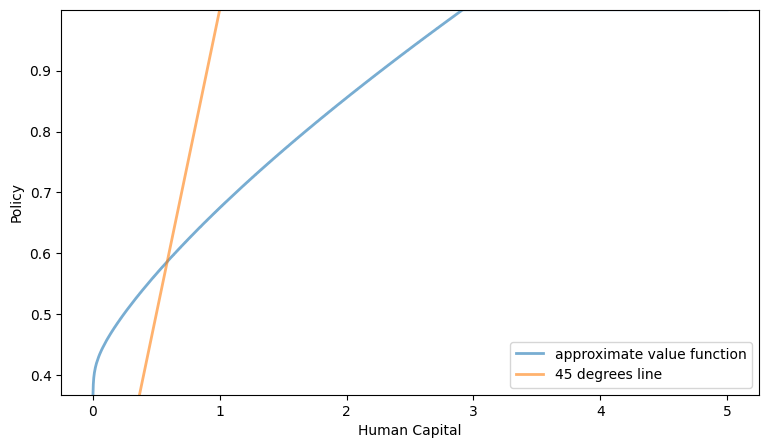

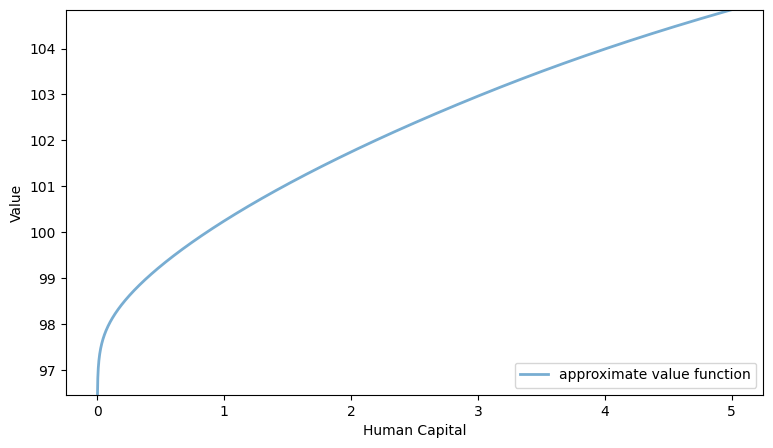

In [9]:
greedy_solver.plot_results("Policy")
greedy_solver.plot_results("Value")

In [10]:
greedy_results = greedy_solver.get_results()
greedy_results

{'Value': array([ 96.46247864,  96.69133927,  96.82046907, ..., 104.84309192,
        104.84407406, 104.84505599], shape=(4000,)),
 'Policy': array([0.36782627, 0.37869653, 0.38486306, ..., 0.99999612, 0.99999608,
        0.99999605], shape=(4000,)),
 'Output': None,
 'Control': None}

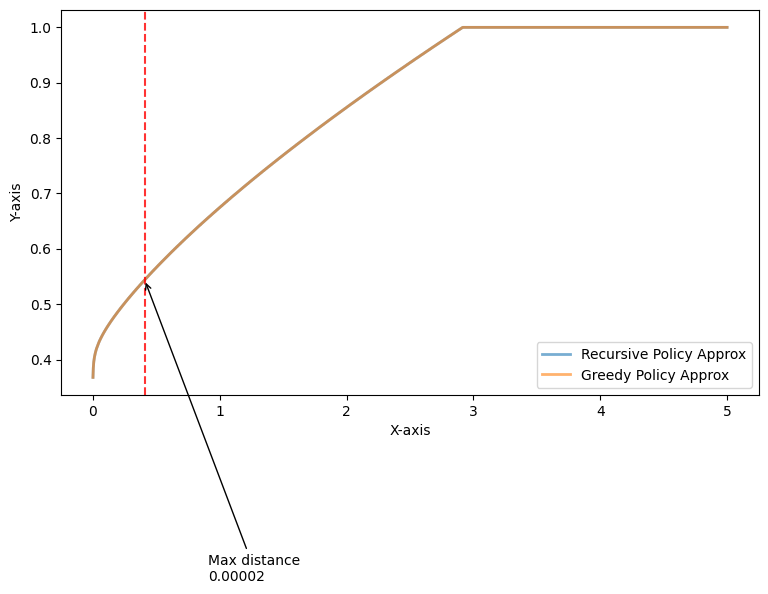

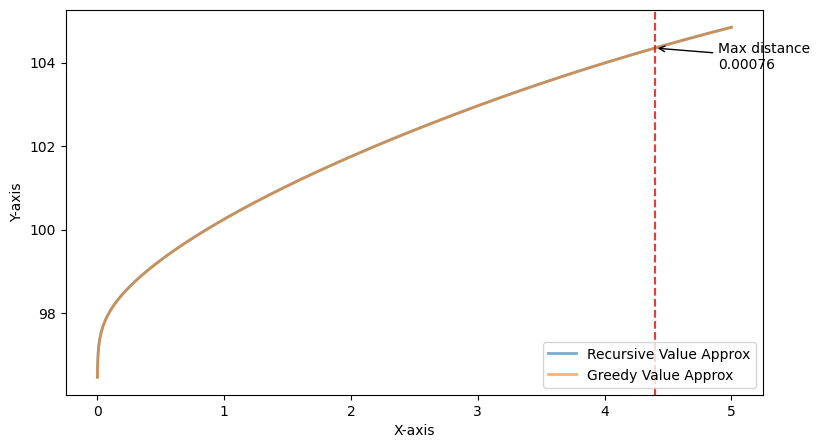

In [11]:
compare_approx(
    grid,
    recursive_results["Policy"],
    greedy_results["Policy"],
    "Recursive Policy Approx",
    "Greedy Policy Approx",
)

compare_approx(
    grid,
    recursive_results["Value"],
    greedy_results["Value"],
    "Recursive Value Approx",
    "Greedy Value Approx",
)

The two methods of estimation yield close approximation of the value and the policy function. 

### Optionnal Question

The initial problem is:

$$\sum_{t=0}^{+\infty} \beta^t \frac{C_t^{1-\sigma}}{1-\sigma}$$

subject to the following constraints: 
1. The production function, $\forall t, C_t = H_t^\alpha L_t$
2. The state transition equation, $\forall t, H_{t+1} = (1-\delta)H_t + 1 - L_t$
3. The control domain, $\forall t, L_{t} \in [0,1]$

The lagrangian is given by:

$$\mathcal{L}=\sum_{t=0}^{+\infty} \beta^t \frac{(H_t^\alpha L_t)^{1-\sigma}}{1-\sigma} + \sum_{t=0}^{+\infty}\lambda_t\left[(1-\delta)H_t + 1 - L_t -H_{t+1}\right]$$

Using the F.O.C. condition we get:

1. w.r.t. to $L_t$: $\quad$ $\beta^tC_t^{-\sigma}H_t^\alpha=\lambda_t$
2. w.r.t. to $H_t$: $\quad$ $\beta^tC_t^{-\sigma}\alpha H_t^{\alpha-1}L_t + (1-\delta)\lambda_t - \lambda_{t-1}=0$

Using 1. in 2. gives the euler equation:

$$C_t^{-\sigma}H_t^\alpha=\beta C_{t+1}^{-\sigma}\left[\alpha H_{t+1}^{\alpha - 1}L_{t+1} + (1-\delta)H_{t+1}^\alpha\right]$$

To approximate the value function with a Neural Network, we will define and use a loss function as a weighted sum of the following quantities:

1. The law of motion: $||H_{t+1} - (1-\delta)H_t + 1 - L_t||$
2. The euler equation: $||C_t^{-\sigma}H_t^\alpha - \beta C_{t+1}^{-\sigma}\left[\alpha H_{t+1}^{\alpha - 1}L_{t+1} + (1-\delta)H_{t+1}^\alpha\right]||$
3. The initial condition: $||\hat{H}_0 - H_0||$

In [9]:
from src.neural_network.nn_method import *

In [43]:
grid_data = GridData(max_T=250, batch_size=50)
train_loader = grid_data.loader
num_epochs = 1001

In [44]:
q_hat = NN(h_0=1e-3, layers=8)
learning_rate = 1e-3
optimizer = torch.optim.Adam(q_hat.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)

In [45]:
print(q_hat)

NN(
  (q): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Tanh()
    (12): Linear(in_features=128, out_features=128, bias=True)
    (13): Tanh()
    (14): Linear(in_features=128, out_features=128, bias=True)
    (15): Tanh()
    (16): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [46]:
for epoch in range(num_epochs):
    for time in train_loader:
        loss, loss_1, loss_2, loss_3 = q_hat.compute_loss(time, weight=np.array([0.3, 0.4, 0.3]))

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    scheduler.step()

    if epoch == 0:
        print(
            "epoch",
            ",",
            "loss",
            ",",
            "loss_motion",
            ",",
            "loss_euler",
            ",",
            "loss_initial",
            ",",
            "lr_rate",
        )
    if epoch % 100 == 0:
        print(
            epoch,
            ",",
            "{:.2e}".format(loss.detach().numpy()),
            ",",
            "{:.2e}".format(loss_1.detach().numpy()),
            ",",
            "{:.2e}".format(loss_2.detach().numpy()),
            ",",
            "{:.2e}".format(loss_3.detach().numpy()),
            ",",
            "{:.2e}".format(get_lr(optimizer)),
        )

epoch , loss , loss_motion , loss_euler , loss_initial , lr_rate
0 , 9.02e-02 , 1.35e-01 , 2.64e-02 , 1.31e-01 , 1.00e-03
100 , 9.56e-04 , 1.48e-03 , 1.09e-03 , 2.56e-04 , 8.00e-04
200 , 8.74e-05 , 5.29e-05 , 9.30e-05 , 1.14e-04 , 6.40e-04
300 , 2.63e-05 , 4.60e-06 , 1.22e-05 , 6.69e-05 , 5.12e-04
400 , 1.55e-05 , 5.49e-06 , 6.71e-06 , 3.71e-05 , 4.10e-04
500 , 8.34e-06 , 1.54e-06 , 8.62e-07 , 2.51e-05 , 3.28e-04
600 , 6.71e-06 , 8.04e-07 , 2.21e-06 , 1.86e-05 , 2.62e-04
700 , 5.21e-06 , 6.16e-07 , 1.67e-06 , 1.45e-05 , 2.10e-04
800 , 4.35e-06 , 4.29e-07 , 1.72e-06 , 1.18e-05 , 1.68e-04
900 , 3.59e-06 , 4.27e-07 , 1.35e-06 , 9.74e-06 , 1.34e-04
1000 , 3.34e-06 , 3.20e-07 , 1.96e-06 , 8.22e-06 , 1.07e-04


In [47]:
time_test = grid_data.time_range
h_hat_path = q_hat(time_test)[:, [0]].detach()
l_hat_path = q_hat(time_test)[:, [1]].detach()

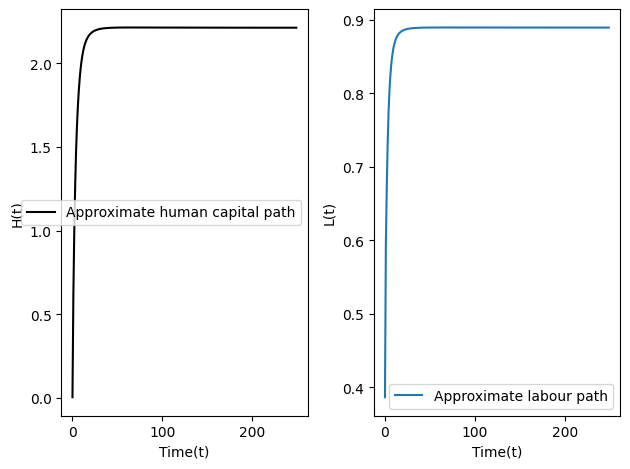

In [48]:
plt.subplot(1, 2, 1)

plt.plot(time_test, h_hat_path, color="k", label=r"Approximate human capital path")
plt.ylabel(r"H(t)")
plt.xlabel(r"Time(t)")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(time_test, l_hat_path, label=r"Approximate labour path")
plt.ylabel(r"L(t)")
plt.xlabel(r"Time(t)")
plt.tight_layout()
plt.legend(loc="best")
plt.tight_layout()
plt.show()

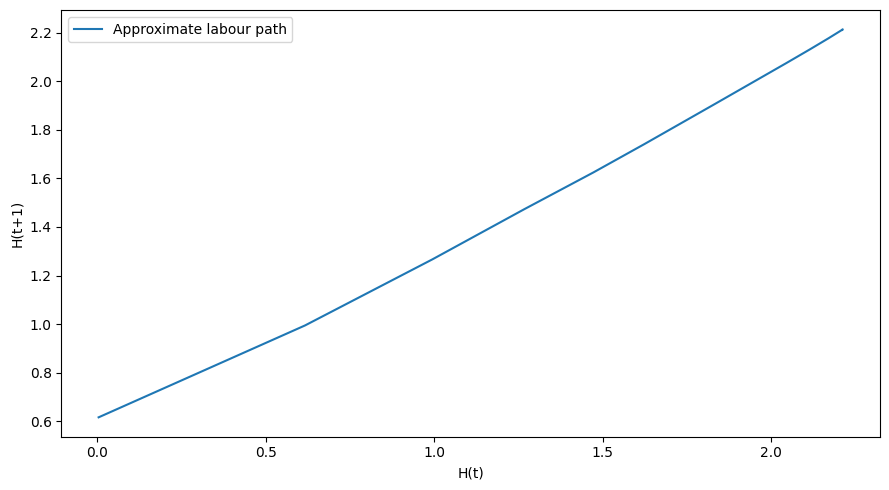

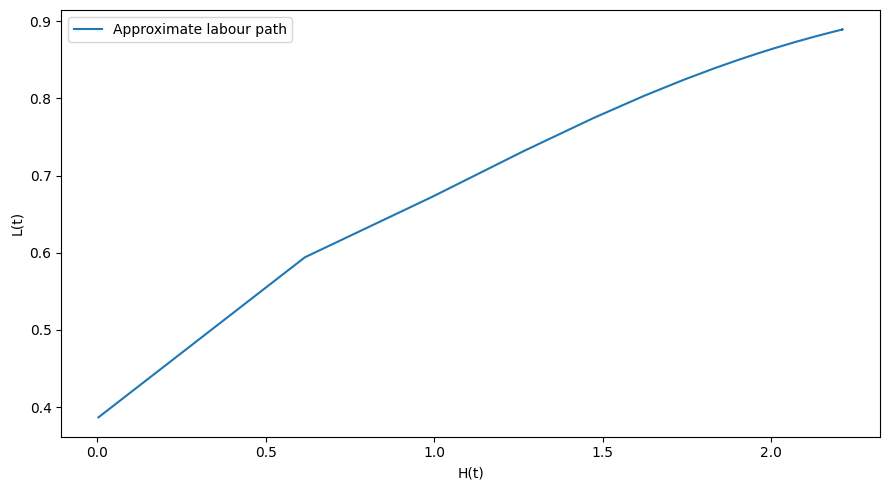

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_hat_path[:-1], h_hat_path[1:], label=r"Approximate labour path")
plt.ylabel(r"H(t+1)")
plt.xlabel(r"H(t)")
plt.tight_layout()
plt.legend(loc="best")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_hat_path, l_hat_path, label=r"Approximate labour path")
plt.ylabel(r"L(t)")
plt.xlabel(r"H(t)")
plt.tight_layout()
plt.legend(loc="best")
plt.tight_layout()
plt.show()